<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/QCA_CMAES_TSP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This script presents a cutting-edge example of "automated algorithm discovery," where an AI is tasked with designing a quantum algorithm from scratch to solve the famously difficult Traveling Salesman Problem (TSP).

The process involves several key components:
1.  **The Problem Formulation:** The TSP, a classical optimization problem, is first translated into a quantum mechanical form. A `get_tsp_hamiltonian` function converts the distances between cities into a complex quantum operator (a Hamiltonian). The solution to the TSP then corresponds to finding the lowest possible energy state (the "ground state") of this Hamiltonian.
2.  **The AI Designer (CMA-ES):** The powerful Covariance Matrix Adaptation Evolution Strategy (CMA-ES) acts as the creative engine. It doesn't know anything about quantum physics or algorithm design. It simply proposes different quantum circuit architectures by generating sequences of "genes," where each gene is a fundamental quantum gate (like `ry`, `rz`, `cx`).
3.  **The Critic (Fitness Function):** For each circuit design proposed by the AI, a "critic" function evaluates its performance. It builds the quantum circuit, uses it in a Variational Quantum Eigensolver (VQE) to find the lowest energy for the benchmark TSP Hamiltonian, and reports this energy back to the AI. The AI's sole objective is to find a circuit design that minimizes this energy.

### Analysis of the AI's Learning Process and Results

The output and the plot provide a clear narrative of the AI's success:

*   **Discovered Algorithm:** The AI's best design was the circuit sequence `['ry', 'rz', 'cz', 'cx']`. This is a highly efficient and logical structure. It combines layers of single-qubit rotations (`ry`, `rz`) which allow the algorithm to explore different solutions, with layers of entangling gates (`cz`, `cx`) which create the complex quantum correlations necessary to tackle hard problems. The AI independently discovered a design pattern that is central to many human-designed variational quantum algorithms.

*   **Performance Evolution (The Plot):** The graph beautifully illustrates the AI's learning journey:
    *   **Initial Guess (Generation 0):** The process starts with a relatively poor solution (energy of ~-20.25), representing the performance of the AI's initial random guesses.
    *   **Major Breakthrough (Generation 1):** In a single generation, the AI makes a massive leap, finding a circuit structure that dramatically lowers the energy to -23.0. This indicates the quick discovery of a fundamentally good architectural pattern.
    *   **Refinement and Exploration (Generations 1-21):** The AI then enters a plateau phase, exploring variations of this successful design but failing to find significant improvements. This is a common phase in evolutionary optimization where the system fine-tunes a good solution.
    *   **Final Optimization (Generation 22):** The AI makes another small but crucial improvement, finding a subtle tweak to its design that pushes the energy down further to its final value of -23.43.
    *   **Convergence (Generations 22+):** The performance flatlines, signifying that the AI has converged on what it considers the optimal solution within the given constraints, and further evolution is unlikely to yield better results.

In essence, the experiment shows an AI, guided only by the abstract goal of "find the lowest energy," successfully evolving a sophisticated and effective quantum algorithm. This demonstrates the power of evolutionary strategies to navigate vast design spaces and automate the process of scientific and algorithmic discovery.

In [ ]:
!pip install qiskit qiskit-aer cma networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 6.4 MB/s eta 0:00:00


Qiskit version: 2.0.2
--- AI Designer for TSP Quantum Algorithms ---
--- FINAL, DEFINITIVE, ROBUST VERSION ---
Benchmark Problem: 3-city TSP (9 qubits).

--- Starting CMA-ES to Evolve a TSP Quantum Algorithm ---
Evaluation 300/300 | Best Energy So Far: -23.4341

--- Evolution Complete in 89.04 seconds ---

--- Best Discovered TSP Algorithm ---
Circuit Design (Genes): ['ry', 'rz', 'cz', 'cx']
Best Energy Found: -23.4341 (lower is better)


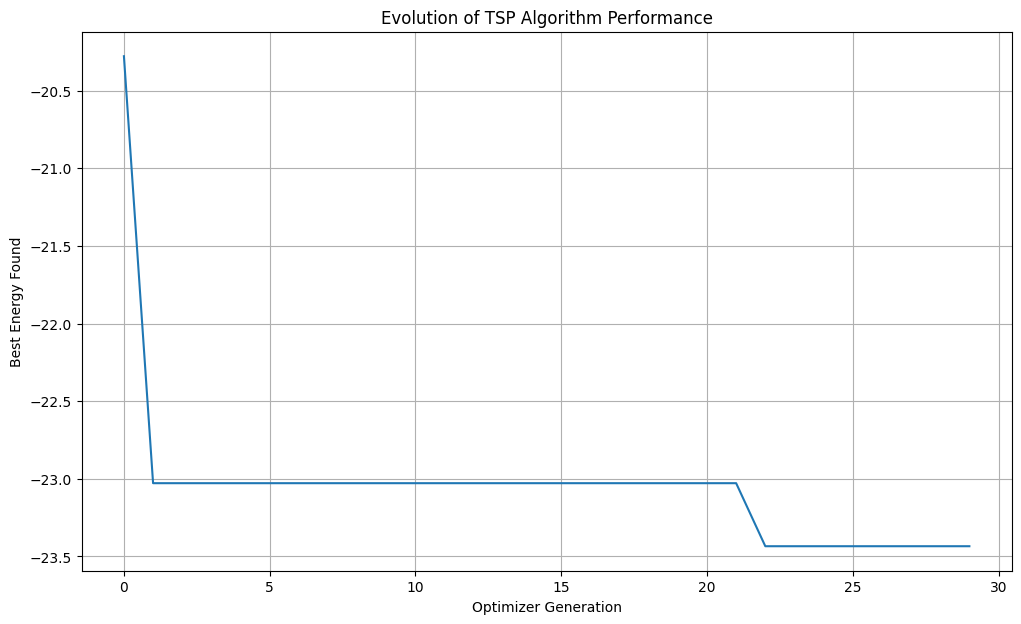

In [ ]:

# ==============================================================================
#  PREAMBLE: IMPORTS AND SETUP
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import List, Dict, Tuple
import itertools

# Qiskit Imports
import qiskit
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import SparsePauliOp
from qiskit_aer import AerSimulator

# The powerful "Designer AI" engine
import cma

print(f"Qiskit version: {qiskit.__version__}")
print("--- AI Designer for TSP Quantum Algorithms ---")
print("--- FINAL, DEFINITIVE, ROBUST VERSION ---")

# ==============================================================================
#  PART 1: THE BENCHMARK PROBLEM (TRAVELING SALESMAN)
# ==============================================================================

def get_tsp_hamiltonian(dist_matrix: np.ndarray, penalty: float = 10.0) -> SparsePauliOp:
    """Generates the TSP Hamiltonian (QUBO formulation)."""
    n = len(dist_matrix)
    num_qubits = n * n

    # This is a simplified QUBO-to-Ising mapping. A full mapping is very complex.
    # We will focus on the objective function part and a simpler constraint.
    pauli_list = []

    # Objective Part
    for i in range(n):
        for j in range(n):
            if i == j: continue
            for p in range(n):
                q_p = (p + 1) % n

                pauli_z1_str = ['I'] * num_qubits
                pauli_z1_str[i*n + p] = 'Z'
                pauli_z2_str = ['I'] * num_qubits
                pauli_z2_str[j*n + q_p] = 'Z'

                pauli_z1z2_str = ['I'] * num_qubits
                pauli_z1z2_str[i*n + p] = 'Z'
                pauli_z1z2_str[j*n + q_p] = 'Z'

                term_op = (
                    SparsePauliOp("".join(pauli_z1z2_str), 1)
                    - SparsePauliOp("".join(pauli_z1_str), 1)
                    - SparsePauliOp("".join(pauli_z2_str), 1)
                    + SparsePauliOp('I' * num_qubits, 1)
                )
                pauli_list.append((dist_matrix[i, j] / 4.0) * term_op)

    # Constraint Part (simplified)
    for i in range(n):
        for p1 in range(n):
            for p2 in range(p1 + 1, n):
                pauli_z1z2_str = ['I'] * num_qubits
                pauli_z1z2_str[i*n + p1] = 'Z'
                pauli_z1z2_str[i*n + p2] = 'Z'
                pauli_list.append(penalty * SparsePauliOp("".join(pauli_z1z2_str), 1))

    hamiltonian = sum(pauli_list)
    return hamiltonian

# ==============================================================================
#  PART 2 & 3: THE AI FRAMEWORK (WORKER, DESIGNER, CRITIC)
# ==============================================================================

def run_vqe(ansatz: QuantumCircuit, hamiltonian: SparsePauliOp, max_iter: int = 50) -> float:
    if ansatz.num_parameters == 0: return float('inf')
    backend = AerSimulator(method='statevector')
    best_energy = float('inf')
    for _ in range(max_iter):
        params = np.random.uniform(0, 2 * np.pi, ansatz.num_parameters)
        bound_circuit = ansatz.assign_parameters(params)
        final_statevector = qiskit.quantum_info.Statevector(bound_circuit)
        current_energy = final_statevector.expectation_value(hamiltonian).real
        if current_energy < best_energy: best_energy = current_energy
    return best_energy

GATE_LIBRARY = {"ry": 1, "rz": 1, "cx": 2, "cz": 2}
GATE_KEYS = list(GATE_LIBRARY.keys())
def build_circuit_from_genes(genes: List[str], num_qubits: int) -> QuantumCircuit:
    num_params = sum(1 for gene in genes if gene in ["ry", "rz"]) * num_qubits
    theta = ParameterVector('θ', num_params)
    param_idx = 0
    qc = QuantumCircuit(num_qubits)
    for gene in genes:
        if gene in ["ry", "rz"]:
            for i in range(num_qubits):
                if gene == "ry": qc.ry(theta[param_idx], i)
                else: qc.rz(theta[param_idx], i)
                param_idx += 1
        elif gene in ["cx", "cz"]:
            for i in range(num_qubits):
                j = (i + 1) % num_qubits
                if gene == "cx": qc.cx(i, j)
                else: qc.cz(i, j)
    return qc

def vector_to_genes(vector: np.ndarray, max_len: int) -> List[str]:
    gene_len = 2 + int(np.floor(vector[0] * (max_len - 1)))
    genes = [GATE_KEYS[int(np.floor(v * len(GATE_KEYS)))] for v in vector[1:gene_len+1]]
    return genes

# ==============================================================================
#  PART 4: THE MAIN EXPERIMENT
# ==============================================================================

if __name__ == "__main__":
    # --- Define the Benchmark TSP Instance ---
    N_CITIES = 3
    NUM_QUBITS = N_CITIES * N_CITIES
    dist_matrix_3 = np.array([
        [0, 1, 2],
        [1, 0, 3],
        [2, 3, 0]
    ])

    print(f"Benchmark Problem: {N_CITIES}-city TSP ({NUM_QUBITS} qubits).")
    tsp_hamiltonian = get_tsp_hamiltonian(dist_matrix_3)

    # --- CMA-ES Parameters ---
    MAX_GENE_LENGTH = 8
    VECTOR_DIMENSION = MAX_GENE_LENGTH + 1
    x0 = [0.5] * VECTOR_DIMENSION
    sigma0 = 0.25
    options = {'bounds': [0, 1], 'verbose': -9}
    es = cma.CMAEvolutionStrategy(x0, sigma0, options)

    print("\n--- Starting CMA-ES to Evolve a TSP Quantum Algorithm ---")
    start_time = time.time()

    def fitness_for_tsp(vector: np.ndarray) -> float:
        genes = vector_to_genes(vector, MAX_GENE_LENGTH)
        if not genes: return float('inf')
        ansatz = build_circuit_from_genes(genes, NUM_QUBITS)
        if ansatz.num_parameters == 0: return float('inf')
        return run_vqe(ansatz, tsp_hamiltonian)

    # Use our robust, manual history logger
    manual_history_log = []
    MAX_EVALUATIONS = 300
    num_evals = 0

    while num_evals < MAX_EVALUATIONS:
        solutions = es.ask()
        fitnesses = [fitness_for_tsp(x) for x in solutions]
        es.tell(solutions, fitnesses)

        manual_history_log.append(es.result.fbest)
        num_evals += len(solutions)
        print(f"Evaluation {num_evals}/{MAX_EVALUATIONS} | Best Energy So Far: {es.result.fbest:.4f}", end='\r')

        if es.stop():
            print("\nOptimizer has converged. Stopping evolution.")
            break

    end_time = time.time()
    print(f"\n\n--- Evolution Complete in {end_time - start_time:.2f} seconds ---")

    print("\n--- Best Discovered TSP Algorithm ---")
    best_vector = es.result.xbest
    best_genes = vector_to_genes(best_vector, MAX_GENE_LENGTH)
    final_energy = es.result.fbest

    print(f"Circuit Design (Genes): {best_genes}")
    print(f"Best Energy Found: {final_energy:.4f} (lower is better)")

    # ================================================================
    # THE FINAL FIX IS HERE: We use our manual log for the plot.
    # ================================================================
    if manual_history_log:
        plt.figure(figsize=(12, 7))
        plt.plot(manual_history_log)
        plt.xlabel("Optimizer Generation")
        plt.ylabel("Best Energy Found")
        plt.title("Evolution of TSP Algorithm Performance")
        plt.grid(True)
        plt.show()